In [63]:
import kagglehub
import numpy as np
import pandas as pd
import os
path=kagglehub.dataset_download('blastchar/telco-customer-churn')
print(os.listdir(path))
file_path=os.path.join(path,'WA_Fn-UseC_-Telco-Customer-Churn.csv')
df=pd.read_csv(file_path)

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [64]:
print(df.head())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [65]:
print(df.info())
df=df.drop(columns="customerID")

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [66]:

for column in df.columns:
    print(f"Unique values in column '{column}':")
    print(df[column].unique())    
    print("-" * 50)
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors='coerce')
print(df.info())

Unique values in column 'gender':
<StringArray>
['Female', 'Male']
Length: 2, dtype: str
--------------------------------------------------
Unique values in column 'SeniorCitizen':
[0 1]
--------------------------------------------------
Unique values in column 'Partner':
<StringArray>
['Yes', 'No']
Length: 2, dtype: str
--------------------------------------------------
Unique values in column 'Dependents':
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
Unique values in column 'tenure':
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
--------------------------------------------------
Unique values in column 'PhoneService':
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
--------------------------------------------------
Unique values in column 'MultipleLine

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encode=OneHotEncoder(drop="first")
cat=df.select_dtypes(include=['object','str'])
cat=encode.fit_transform(cat)
encoded_df = pd.DataFrame(cat.toarray(), columns=encode.get_feature_names_out())
print(encoded_df)
df=df.join(encoded_df)
print(df.info())

      gender_Male  Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0             0.0          1.0             0.0               0.0   
1             1.0          0.0             0.0               1.0   
2             1.0          0.0             0.0               1.0   
3             1.0          0.0             0.0               0.0   
4             0.0          0.0             0.0               1.0   
...           ...          ...             ...               ...   
7038          1.0          1.0             1.0               1.0   
7039          0.0          1.0             1.0               1.0   
7040          0.0          1.0             1.0               0.0   
7041          1.0          1.0             0.0               1.0   
7042          1.0          0.0             0.0               1.0   

      MultipleLines_No phone service  MultipleLines_Yes  \
0                                1.0                0.0   
1                                0.0                0.0   
2     

In [69]:
cat = df.select_dtypes(include=['object', 'str'])  # Cột phân loại
df = df.drop(columns=cat.columns)  # Drop các cột phân loại
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7043 non-null   int64  
 1   tenure                                 7043 non-null   int64  
 2   MonthlyCharges                         7043 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7043 non-null   float64
 5   Partner_Yes                            7043 non-null   float64
 6   Dependents_Yes                         7043 non-null   float64
 7   PhoneService_Yes                       7043 non-null   float64
 8   MultipleLines_No phone service         7043 non-null   float64
 9   MultipleLines_Yes                      7043 non-null   float64
 10  InternetService_Fiber optic            7043 non-null   float64
 11  InternetService

<Axes: >

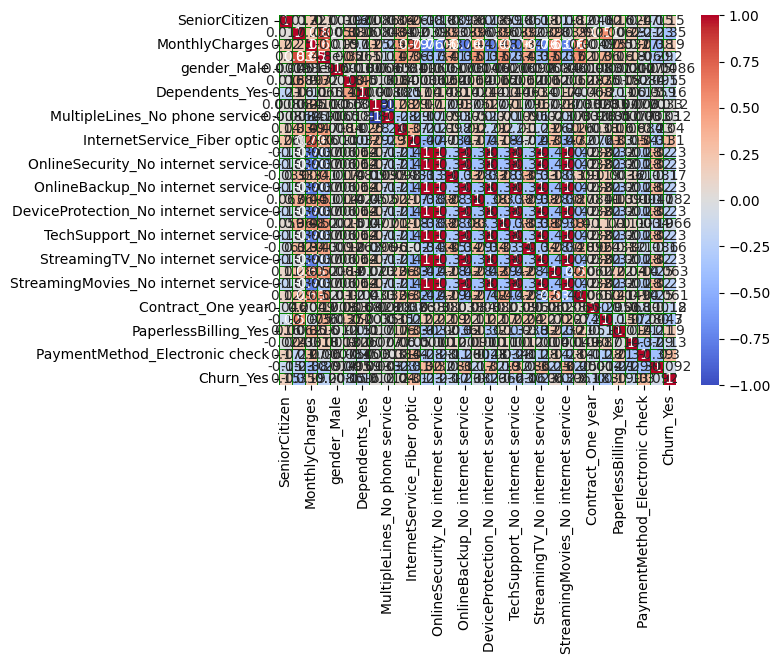

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_df=df.corr()
sns.heatmap(corr_df,annot=True,cmap='coolwarm',linewidths=0.5,linecolor='green')

In [82]:
y=df.Churn_Yes
x=df.drop(columns="Churn_Yes")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
impute=SimpleImputer(strategy="median")
x=pd.DataFrame(impute.fit_transform(x))
model=LogisticRegression(max_iter=1000)
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,shuffle=True)
model.fit(x_train,y_train)
predictions=model.predict(x_test)
print("percent right predictions:",accuracy_score(y_test,predictions))

percent right predictions: 0.8204400283889283
